In [66]:
from pathlib import Path

import matplotlib.pyplot as plt

import cv2

import numpy as np

import pandas as pd

In [67]:
data_dir = Path('/work/cvcs2026/LZMM/IREye4Task')

annotation_paths = list(Path(data_dir).glob('*.txt'))

print(annotation_paths[0])
annotations = pd.read_csv(
    annotation_paths[0],
    sep=r'\s+',
    skiprows=1,
    header=None
)

annotations = annotations.rename(columns={0: 'timeStamp', 1: 'eyeState'})

coord_cols = annotations.columns[2:]
annotations['eyeLandmarks'] = annotations[coord_cols].values.tolist()
annotations = annotations.drop(columns=coord_cols)

display(annotations.head())
display(annotations.dtypes)

/work/cvcs2026/LZMM/IREye4Task/eye0_sub8.txt


,timeStamp,eyeState,eyeLandmarks
0,0.000000,0,"[104.7142, 179.4359, 262.1383, 354.7672, 446.0..."
1,0.016667,0,"[106.067, 183.9264, 262.8154, 352.4123, 444.92..."
2,0.033333,0,"[107.3322, 180.3113, 257.4263, 348.9554, 441.7..."
3,0.050000,0,"[106.6143, 180.0832, 258.7578, 350.4677, 442.5..."
4,0.066667,0,"[106.7448, 181.0957, 259.6215, 351.4524, 444.0..."


timeStamp       float64
eyeState          int64
eyeLandmarks     object
dtype: object

In [68]:
subject_id = int(annotation_paths[0].stem.replace('eye0_sub', '').replace('.txt', ''))
annotations['subjectID'] = subject_id
annotations = annotations.loc[:, ['subjectID', 'timeStamp', 'eyeState', 'eyeLandmarks']]

display(annotations.head())

,subjectID,timeStamp,eyeState,eyeLandmarks
0,8,0.000000,0,"[104.7142, 179.4359, 262.1383, 354.7672, 446.0..."
1,8,0.016667,0,"[106.067, 183.9264, 262.8154, 352.4123, 444.92..."
2,8,0.033333,0,"[107.3322, 180.3113, 257.4263, 348.9554, 441.7..."
3,8,0.050000,0,"[106.6143, 180.0832, 258.7578, 350.4677, 442.5..."
4,8,0.066667,0,"[106.7448, 181.0957, 259.6215, 351.4524, 444.0..."


In [69]:
FRAME_NUMBER = 100

/work/cvcs2026/LZMM/IREye4Task/eye0_sub8
/work/cvcs2026/LZMM/IREye4Task/eye0_sub8/frame_000100.jpg
(480, 640, 3)


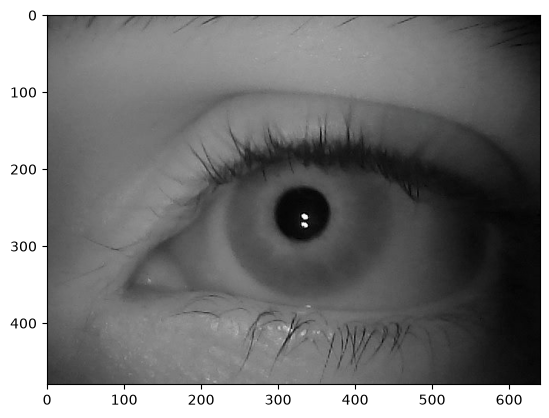

In [70]:
video_dir = Path(data_dir.joinpath(annotation_paths[0].stem))
print(video_dir)

frame_paths = list(video_dir.glob('*'))
frame_paths.sort()
print(frame_paths[FRAME_NUMBER])

frame = cv2.imread(str(frame_paths[FRAME_NUMBER]))
print(frame.shape)        # H, W, C
frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
frame = np.flip(frame, axis=0)
plt.figure()
plt.imshow(frame)
plt.show()

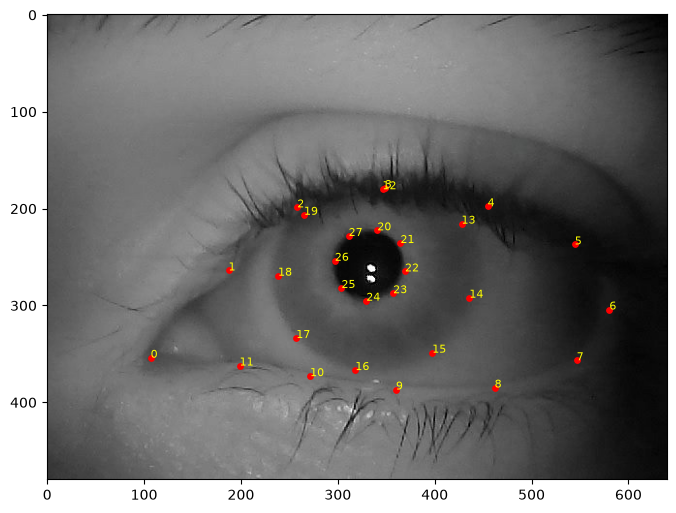

In [71]:
raw = np.array(annotations['eyeLandmarks'][FRAME_NUMBER], dtype=np.float32)
xs = raw[:28]
ys = raw[28:]
pts_flat = np.stack([xs, ys], axis=1)

plt.figure(figsize=(8,8))
plt.imshow(frame)
plt.scatter(pts_flat[:,0], pts_flat[:,1], c='red', s=15)
for i, (x, y) in enumerate(pts_flat):
    plt.text(x, y, str(i), color='yellow', fontsize=8)
plt.show()

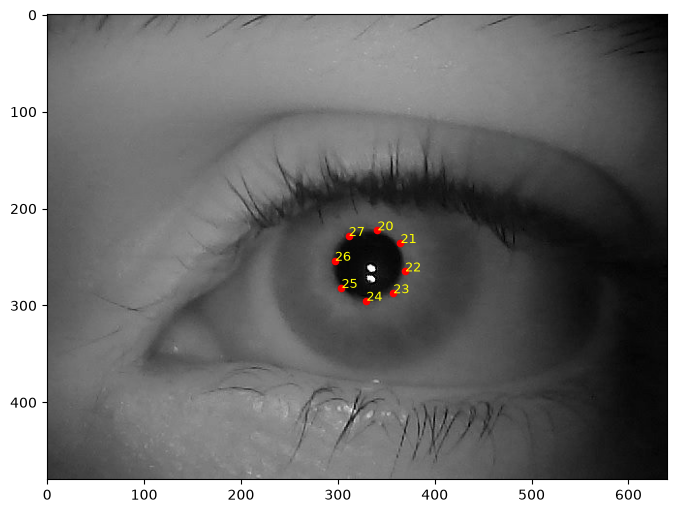

In [72]:
pupil_indices = [20, 21, 22, 23, 24, 25, 26, 27]

pupil_pts = pts_flat[pupil_indices]

plt.figure(figsize=(8,8))
plt.imshow(frame)
plt.scatter(pupil_pts[:,0], pupil_pts[:,1], c='red', s=20)
for idx, (x, y) in enumerate(pupil_pts):
    plt.text(x, y, str(pupil_indices[idx]), color='yellow', fontsize=9)
plt.show()

(480, 640)


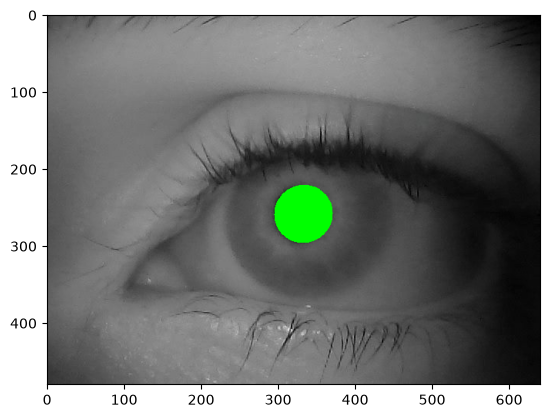

In [ ]:
pupil_pts_int = pupil_pts.astype(np.int32)

ellipse = cv2.fitEllipse(pupil_pts_int)

mask = np.zeros(frame.shape).astype(np.uint8)
cv2.ellipse(mask, ellipse, color=(0, 255, 0), thickness=-1)  # thickness=-1 = filled
overlap = frame.copy()
overlap[mask[:, :, 1] > 0, :] = (0, 255, 0)

plt.imshow(overlap)
plt.show()

In [74]:
label_paths = list(data_dir.glob('*.csv'))

print(label_paths[0])
labels = pd.read_csv(label_paths[0])
labels['taskType'] = labels['Var1']
labels['cload'] = labels['Var2']
labels = labels.drop(columns=['Var1', 'Var2'])

display(labels.head())

/work/cvcs2026/LZMM/IREye4Task/tasks_sub20.csv


,taskType,cload
0,befExp,pause
1,befExp,pause
2,befExp,pause
3,befExp,pause
4,befExp,pause
